In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

from openap import FuelFlow, Emission
from openap.phase import FlightPhase

# ---------------------------------------------------------------------------
# CONFIG — edit these for your setup
# ---------------------------------------------------------------------------
DATA_DIR = '/Users/ramupadhyay/Desktop/ny_to_florida_p'
AC_TYPE  = 'A321'          # change if a different aircraft type
INITIAL_MASS_KG = 75000     # starting mass assumption — adjust based on load

# ---------------------------------------------------------------------------
# Dark theme for plots
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
})
DARK, PANEL, GRID = '#0d1117', '#161b22', '#21262d'
WHITE, MUTED = '#c9d1d9', '#8b949e'
CYAN, GREEN, ORANGE, RED, PURPLE, YELLOW = '#58a6ff','#3fb950','#f0883e','#f85149','#bc8cff','#e3b341'
CAT_COLORS = [GREEN, CYAN, ORANGE, RED]
CAT_NAMES  = ['Nil', 'Light', 'Moderate', 'Severe']

print('Setup OK')

Setup OK


In [10]:
# ---------------------------------------------------------------------------
# USE_HIGH_RES controls the base time grid:
#   False (default) -> 1Hz GPS grid  -> ~5400 rows for a 90-min flight
#   True            -> 10Hz IMU grid -> ~54000 rows, better turbulence resolution
#
# In both cases every sensor is aligned via nearest-time join (merge_asof),
# so the fractional-second offsets between sensor files are handled correctly.
# ---------------------------------------------------------------------------
USE_HIGH_RES = True   # set True for full 10Hz turbulence resolution

# Step 1: shift all files so common overlap starts at t=0
# (t0 = latest first-sample across all files — before this point
#  at least one sensor hasn't started yet, so we discard that window)
t0 = max(df.time.iloc[0] for df in raw.values())
for k in raw:
    raw[k] = raw[k].copy()
    raw[k]['time'] = raw[k]['time'] - t0
    raw[k] = raw[k][raw[k]['time'] >= 0].reset_index(drop=True)

# Step 2: choose base grid
if USE_HIGH_RES:
    base = raw['acc'][['time']].copy()   # 10Hz — more rows, better EDR
    print('Using 10Hz IMU grid (high-res mode)')
else:
    base = raw['loc'][['time']].copy()   # 1Hz GPS — GPS-anchored
    print('Using 1Hz GPS grid (default mode)')

# Step 3: nearest-time join — handles fractional-second offsets between files.
# TOL=0.1s means 'match only if within half a 10Hz sample period'.
# Rows with no match within tolerance become NaN and are dropped later.
TOL = pd.Timedelta('0.1s')

def asof_merge(base_df, other_df, prefix):
    a = base_df.copy()
    b = other_df.copy()
    a['__t'] = pd.to_timedelta(a['time'], unit='s')
    b['__t'] = pd.to_timedelta(b['time'], unit='s')
    b = b.drop(columns=['time']).add_prefix(prefix)
    b = b.rename(columns={f'{prefix}__t': '__t'})
    merged = pd.merge_asof(a.sort_values('__t'), b.sort_values('__t'),
                            on='__t', tolerance=TOL, direction='nearest')
    return merged.drop(columns='__t')

# Step 4: merge all IMU sensors onto the base grid
df = base.copy()
for k in ['acc', 'lin', 'gyr', 'grv', 'ori']:
    df = asof_merge(df, raw[k], f'{k}_')

# Step 5: bring in Location (GPS) columns.
# In GPS-grid mode: concat directly (same rows, same order).
# In high-res mode: asof merge GPS onto IMU grid (GPS forward-fills between fixes).
if USE_HIGH_RES:
    df = asof_merge(df, raw['loc'], 'loc_')
    # strip the loc_ prefix so downstream column names stay identical
    df = df.rename(columns={c: c[4:] for c in df.columns if c.startswith('loc_')})
else:
    loc = raw['loc'].drop(columns=['time'])
    df = pd.concat([df, loc.reset_index(drop=True)], axis=1)

df = df.dropna().reset_index(drop=True)
print(f'Merged dataframe: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'Duration: {df.time.iloc[-1]/60:.1f} min')
print(f'Effective rate: {len(df)/df.time.iloc[-1]:.1f} Hz')
df.head()

Using 10Hz IMU grid (high-res mode)
Merged dataframe: 10869 rows x 28 cols
Duration: 128.0 min
Effective rate: 1.4 Hz


,time,acc_Acceleration x (m/s^2),acc_Acceleration y (m/s^2),acc_Acceleration z (m/s^2),lin_Linear Acceleration x (m/s^2),lin_Linear Acceleration y (m/s^2),lin_Linear Acceleration z (m/s^2),gyr_Gyroscope x (rad/s),gyr_Gyroscope y (rad/s),gyr_Gyroscope z (rad/s),...,ori_Yaw (°),ori_Pitch (°),ori_Roll (°),Latitude (°),Longitude (°),Height (m),Velocity (m/s),Direction (°),Horizontal Accuracy (m),Vertical Accuracy (m)
0,0.038218,-1.323994,-8.779537,-3.902549,-0.082532,0.080901,-0.041225,0.004887,-0.003054,0.001833,...,-112.893493,7.425910,0.130270,40.782588,-73.878152,-12.790056,1.98,121.199997,47.0,44.0
1,0.938218,-1.177947,-8.939949,-3.811569,0.081441,0.020522,0.064980,0.000000,0.009163,0.001222,...,-113.554703,7.401945,-0.573441,40.782629,-73.878096,-12.790162,1.29,123.000000,40.5,38.0
2,1.038218,-1.249773,-8.932767,-3.869030,-0.036675,0.010119,0.109570,0.001833,0.009774,0.001222,...,-113.514315,7.370187,-0.676063,40.782629,-73.878096,-12.790162,1.29,123.000000,40.5,38.0
3,1.938218,-1.235408,-9.138668,-3.821146,0.108074,-0.139702,-0.086767,-0.009774,0.013439,0.000000,...,-113.234644,7.528496,-0.654474,40.782577,-73.878043,-6.790099,1.75,118.099998,37.5,37.0
4,2.038218,-1.242591,-8.995016,-3.916914,0.086171,-0.056644,0.058735,0.007941,0.000611,-0.001222,...,-113.225914,7.507920,-0.735801,40.782577,-73.878043,-6.790099,1.75,118.099998,37.5,37.0


In [9]:
import os

def load_csv(name):
    path = os.path.join(DATA_DIR, name)
    df = pd.read_csv(path)
    # first column is always Time (s) in phyphox exports
    time_col = df.columns[0]
    df = df.rename(columns={time_col: 'time'})
    df = df.sort_values('time').reset_index(drop=True)
    return df

files = {
    'loc': 'Location.csv',
    'acc': 'Accelerometer.csv',
    'lin': 'Linear Acceleration.csv',
    'gyr': 'Gyroscope.csv',
    'grv': 'Gravity.csv',
    'ori': 'Orientation.csv',
}

raw = {k: load_csv(v) for k, v in files.items()}

for k, df in raw.items():
    print(f'{k:4s}: {len(df):5d} rows | t = {df.time.iloc[0]:.3f} -> {df.time.iloc[-1]:.3f}s '
          f'| cols = {list(df.columns)}')

loc :  5435 rows | t = 12.852 -> 7692.869s | cols = ['time', 'Latitude (°)', 'Longitude (°)', 'Height (m)', 'Velocity (m/s)', 'Direction (°)', 'Horizontal Accuracy (m)', 'Vertical Accuracy (m)']
acc : 76934 rows | t = 0.000 -> 7692.890s | cols = ['time', 'Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']
lin : 77058 rows | t = 0.000 -> 7692.932s | cols = ['time', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)']
gyr : 76929 rows | t = 0.108 -> 7692.908s | cols = ['time', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)']
grv : 76990 rows | t = 0.000 -> 7692.873s | cols = ['time', 'Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']
ori : 77001 rows | t = 0.000 -> 7692.850s | cols = ['time', 'w', 'x', 'y', 'z', 'Direct (°)', 'Yaw (°)', 'Pitch (°)', 'Roll (°)']


In [11]:
# ---------------------------------------------------------------------------
# Identify key columns by matching on substrings (robust to exact naming
# variations like 'Latitude (\u00b0)' vs 'Latitude')
# ---------------------------------------------------------------------------
def find_col(df, *keywords):
    for c in df.columns:
        cl = c.lower()
        if all(k.lower() in cl for k in keywords):
            return c
    raise KeyError(f'No column matching {keywords} in {list(df.columns)}')

col_lat  = find_col(df, 'Latitude (°)')
col_lon  = find_col(df, 'Longitude (°)')
col_alt  = find_col(df, 'Height (m)')
col_vel  = find_col(df, 'Velocity (m/s)')
col_hdg  = find_col(df, 'Direction (°)')

col_linx = find_col(df, 'Linear Acceleration x (m/s^2)')
col_liny = find_col(df, 'Linear Acceleration y (m/s^2)')
col_linz = find_col(df, 'Linear Acceleration z (m/s^2)')

col_gyrx = find_col(df, 'Gyroscope x (rad/s)')
col_gyry = find_col(df, 'Gyroscope y (rad/s)')
col_gyrz = find_col(df, 'Gyroscope z (rad/s)')

col_pitch = find_col(df, 'ori_', 'Pitch (°)')
col_roll  = find_col(df, 'ori_', 'Roll (°)')
col_yaw   = find_col(df, 'ori_', 'Yaw (°)')

t      = df['time'].values
lat    = df[col_lat].values
lon    = df[col_lon].values
alt_m  = df[col_alt].values
vel_ms = df[col_vel].values
hdg    = df[col_hdg].values

lin_x = df[col_linx].values
lin_y = df[col_liny].values
lin_z = df[col_linz].values

gyr_mag = np.sqrt(df[col_gyrx]**2 + df[col_gyry]**2 + df[col_gyrz]**2).values
pitch   = df[col_pitch].values
roll    = df[col_roll].values
yaw     = df[col_yaw].values

# sampling rate
dt = np.median(np.diff(t))
fs = round(1/dt)
print(f'Sampling rate: {fs} Hz (dt={dt:.3f}s)')
print(f'Duration: {t[-1]/60:.1f} min, {len(t)} samples')
print(f'Altitude: {alt_m.min():.0f} - {alt_m.max():.0f} m')
print(f'Speed: {vel_ms.max()*3.6:.0f} km/h max')

Sampling rate: 2 Hz (dt=0.450s)
Duration: 128.0 min, 10869 samples
Altitude: -46 - 11071 m
Speed: 940 km/h max


In [12]:
W = int(10 * fs)  # 10-second window in samples

edr = np.array([lin_z[i:i+W].std() for i in range(len(t) - W)])
edr = np.append(edr, np.full(W, edr[-1]))

# ICAO-adapted thresholds for phone accelerometer
cat = np.where(edr < 0.04, 0,
      np.where(edr < 0.12, 1,
      np.where(edr < 0.35, 2, 3)))

print(f'Window size: {W} samples ({W/fs:.0f}s)')
print('\nTurbulence summary:')
for c, name in enumerate(CAT_NAMES):
    n = (cat == c).sum()
    print(f'  {name:<10}: {n:5d} samples ({n/len(cat)*100:5.1f}%) = {n/fs:.0f}s')

peak_i = edr.argmax()
print(f'\nPeak EDR: {edr[peak_i]:.3f} m/s² at t={t[peak_i]/60:.1f} min')
print(f'Location: {lat[peak_i]:.4f}N, {lon[peak_i]:.4f}E, alt={alt_m[peak_i]:.0f}m')

Window size: 20 samples (10s)

Turbulence summary:
  Nil       :     0 samples (  0.0%) = 0s
  Light     :  2783 samples ( 25.6%) = 1392s
  Moderate  :  7863 samples ( 72.3%) = 3932s
  Severe    :   223 samples (  2.1%) = 112s

Peak EDR: 0.898 m/s² at t=0.4 min
Location: 40.7812N, -73.8755E, alt=10m


In [20]:
# ---------------------------------------------------------------------------
# Step 1: Outlier removal on raw lin_z
# Sensor spikes (single-sample glitches from USB/WiFi interference or
# mechanical shock) would inflate EDR across the whole surrounding window.
# We clip anything beyond 5 standard deviations from the rolling median.
# ---------------------------------------------------------------------------
from scipy.ndimage import median_filter
from scipy.stats import zscore

lin_z_clean = lin_z.copy()
z_scores    = np.abs(zscore(lin_z))
spike_mask  = z_scores > 5                          # flag spikes
# replace spikes with local median (3-sample window)
lin_z_med   = median_filter(lin_z, size=3)
lin_z_clean[spike_mask] = lin_z_med[spike_mask]
print(f'Spikes removed: {spike_mask.sum()} samples ({spike_mask.sum()/fs:.1f}s)')

# Step 2: Light smoothing to reduce high-frequency sensor noise
# Use a short 0.5s median filter — removes noise but preserves real turbulent bursts
smooth_w    = max(int(0.5 * fs), 1)
lin_z_smooth = median_filter(lin_z_clean.astype(float), size=smooth_w)

# ---------------------------------------------------------------------------
# Step 3: EDR — 10-second sliding window std of cleaned vertical acceleration
# ---------------------------------------------------------------------------
W = int(10 * fs)  # 10-second window in samples

edr = np.array([lin_z_smooth[i:i+W].std() for i in range(len(t) - W)])
edr = np.append(edr, np.full(W, edr[-1]))

# ---------------------------------------------------------------------------
# Step 4: Phase-aware turbulence masking
# Takeoff and landing have large lin_z from: engines spooling up, gear
# retraction/extension, runway bumps, flap deployment. None of this is
# atmospheric turbulence. We mark those phases as NaN in EDR so they
# don't pollute the turbulence statistics or the fuel-vs-turbulence table.
#
# We detect ground/takeoff/landing using speed and altitude:
#   ground    : vel < 5 m/s
#   takeoff   : vel 5-80 m/s AND climbing  (first ~3 min)
#   landing   : vel 5-80 m/s AND descending (last ~3 min)
# ---------------------------------------------------------------------------
flight_only = np.ones(len(t), dtype=bool)

# Ground / very slow (taxi, gate)
flight_only[vel_ms < 5] = False

# Takeoff roll + initial climb: below 3000m AND speed still building
# Use first 5 minutes as a conservative cutoff for takeoff phase
takeoff_end  = int(5 * 60 / dt)           # first 5 min in samples
flight_only[:takeoff_end] = False

# Landing flare + rollout: below 1500m AND decelerating in last 10 min
landing_start = len(t) - int(10 * 60 / dt)  # last 10 min
low_alt_landing = (alt_m < 1500) & (np.arange(len(t)) > landing_start)
flight_only[low_alt_landing] = False

# Apply mask: set EDR to NaN for non-flight samples
edr_masked = edr.copy().astype(float)
edr_masked[~flight_only] = np.nan

# ICAO-adapted thresholds for phone accelerometer
# cat uses masked EDR — NaN samples get cat==-1 (excluded)
cat = np.where(edr_masked < 0.08,  0,     # Nil
      np.where(edr_masked < 0.20,  1,     # Light
      np.where(edr_masked < 0.50,  2, 3)))# Moderate / Severe

print(f'\nWindow size: {W} samples ({W/fs:.0f}s)')
print('\nTurbulence summary (airborne only):')
for c, name in enumerate(CAT_NAMES):
    n = (cat == c).sum()
    airborne = (cat >= 0).sum()
    print(f'  {name:<10}: {n:6d} samples ({n/max(airborne,1)*100:5.1f}%) = {n/fs:.0f}s')
print(f'  Excluded  : {(cat==-1).sum():6d} samples (takeoff/landing/ground)')

valid = ~np.isnan(edr_masked)
if valid.any():
    peak_i = np.nanargmax(edr_masked)
    print(f'\nPeak EDR (airborne): {edr_masked[peak_i]:.3f} m/s\u00b2 at t={t[peak_i]/60:.1f} min')
    print(f'Location: {lat[peak_i]:.4f}N, {lon[peak_i]:.4f}E, alt={alt_m[peak_i]:.0f}m')

# Use edr_masked going forward (NaN during ground/takeoff/landing)
edr = edr_masked

Spikes removed: 20 samples (10.0s)

Window size: 20 samples (10s)

Turbulence summary (airborne only):
  Nil       :    270 samples (  2.5%) = 135s
  Light     :   8805 samples ( 81.0%) = 4402s
  Moderate  :   1058 samples (  9.7%) = 529s
  Severe    :    736 samples (  6.8%) = 368s
  Excluded  :      0 samples (takeoff/landing/ground)

Peak EDR (airborne): 0.335 m/s² at t=28.1 min
Location: 38.5637N, -75.5033E, alt=9527m


In [21]:
alt_ft  = alt_m  * 3.28084
spd_kts = vel_ms * 1.94384

# Vertical rate from smoothed altitude (raw GPS altitude is noisy)
alt_smooth = uniform_filter1d(alt_m.astype(float), size=max(fs*5, 1))
vs_ms  = np.gradient(alt_smooth, t)
vs_fpm = np.clip(vs_ms * 196.85, -3000, 3000)

fp = FlightPhase()
fp.set_trajectory(t, alt_ft, spd_kts, vs_fpm)
phase_labels = np.array(fp.phaselabel())

PHASE_NAMES = {
    'GND': 'ground', 'CL': 'climb', 'LVL': 'level',
    'CR': 'cruise', 'DE': 'descent', 'NA': 'unlabeled',
}
PHASE_COLORS = {
    'ground': '#475569', 'climb': GREEN, 'level': YELLOW,
    'cruise': CYAN, 'descent': ORANGE, 'unlabeled': '#475569',
}
phase = np.array([PHASE_NAMES.get(l, 'unlabeled') for l in phase_labels])

print('Flight phase summary:')
for p in ['ground', 'climb', 'level', 'cruise', 'descent', 'unlabeled']:
    mask = phase == p
    if mask.sum() > 0:
        print(f'  {p:10s}: {mask.sum()/fs:6.0f}s  alt={alt_m[mask].mean():6.0f}m  '
              f'spd={vel_ms[mask].mean()*3.6:5.0f}km/h')

Flight phase summary:
  climb     :   2012s  alt=  9227m  spd=  841km/h
  cruise    :   2063s  alt= 10956m  spd=  892km/h
  descent   :   1324s  alt=  9813m  spd=  857km/h
  unlabeled :     35s  alt=    51m  spd=   30km/h


In [22]:
acc_kts = np.clip(np.gradient(vel_ms, t) * 1.94384, -10, 10)

fuel_model = FuelFlow(ac=AC_TYPE)
emission_model = Emission(ac=AC_TYPE)
IDLE_FLOOR = 0.16  # kg/s, both engines at idle

fuel_flow = np.zeros(len(t))
mass = float(INITIAL_MASS_KG)

for k in range(len(t)):
    try:
        ff = fuel_model.enroute(
            mass=mass,
            tas=max(float(spd_kts[k]), 80),
            alt=max(float(alt_ft[k]), 0),
            vs=float(vs_fpm[k]),
            acc=float(acc_kts[k]),
        )
        ff = float(ff) if ff and not np.isnan(ff) else fuel_flow[k-1]
    except Exception:
        ff = fuel_flow[k-1] if k > 0 else IDLE_FLOOR
    fuel_flow[k] = max(ff, IDLE_FLOOR)
    mass -= fuel_flow[k] * dt   # dt seconds per sample

total_fuel = fuel_flow.sum() * dt
avg_flow_kgmin = fuel_flow.mean() * 60

# Emissions
co2 = emission_model.co2(fuel_flow)                       # g/s
nox = emission_model.nox(fuel_flow, tas=spd_kts, alt=alt_ft)  # g/s
co  = emission_model.co(fuel_flow,  tas=spd_kts, alt=alt_ft)  # g/s

print('=' * 50)
print(f'Aircraft type        : {AC_TYPE}')
print(f'Initial mass         : {INITIAL_MASS_KG:,} kg')
print(f'Duration             : {t[-1]/60:.1f} min')
print(f'Total fuel consumed  : {total_fuel:,.1f} kg')
print(f'Avg fuel flow        : {avg_flow_kgmin:.2f} kg/min '
      f'({avg_flow_kgmin*60:.0f} kg/hr)')
print(f'Total CO2            : {(co2*dt).sum()/1000:,.1f} kg')
print(f'Total NOx            : {(nox*dt).sum():,.1f} g')
print(f'Total CO             : {(co*dt).sum():,.1f} g')
print('=' * 50)

Aircraft type        : A321
Initial mass         : 75,000 kg
Duration             : 128.0 min
Total fuel consumed  : 4,703.2 kg
Avg fuel flow        : 57.70 kg/min (3462 kg/hr)
Total CO2            : 14,862.1 kg
Total NOx            : 99,496.6 g
Total CO             : 13,282.8 g


In [23]:
print(f'{"Phase":<10} {"Category":<10} {"Seconds":>8} {"kg/hr":>8} {"vs Light":>10}')
print('-' * 50)

results = {}
for p in ['climb', 'cruise', 'descent']:
    pm = phase == p
    if pm.sum() < fs * 5:
        continue
    # baseline = light turbulence (most common, avoids noisy single-sample bins)
    base_mask = pm & (cat == 1)
    if base_mask.sum() < fs * 2:
        base_mask = pm
    baseline = fuel_flow[base_mask].mean()

    results[p] = {}
    for c, cname in enumerate(CAT_NAMES):
        mask = pm & (cat == c)
        if mask.sum() < fs * 2:
            continue
        kghr = fuel_flow[mask].mean() * 3600
        pct  = (fuel_flow[mask].mean() / baseline - 1) * 100
        results[p][cname] = {'sec': mask.sum()/fs, 'kghr': kghr, 'pct': pct}
        sign = '+' if pct >= 0 else ''
        print(f'{p:<10} {cname:<10} {mask.sum()/fs:>8.0f} {kghr:>8.0f} {sign}{pct:>9.1f}%')
    print()

Phase      Category    Seconds    kg/hr   vs Light
--------------------------------------------------
climb      Nil              74     4522      -2.3%
climb      Light          1506     4628 +      0.0%
climb      Moderate        204     3800     -17.9%
climb      Severe          228     7261 +     56.9%

cruise     Nil              48     2523     -17.5%
cruise     Light          1871     3059 +      0.0%
cruise     Moderate        144     3179 +      3.9%

descent    Nil              13     3119 +     73.2%
descent    Light          1026     1800 +      0.0%
descent    Moderate        181     2113 +     17.4%
descent    Severe          104     3118 +     73.2%



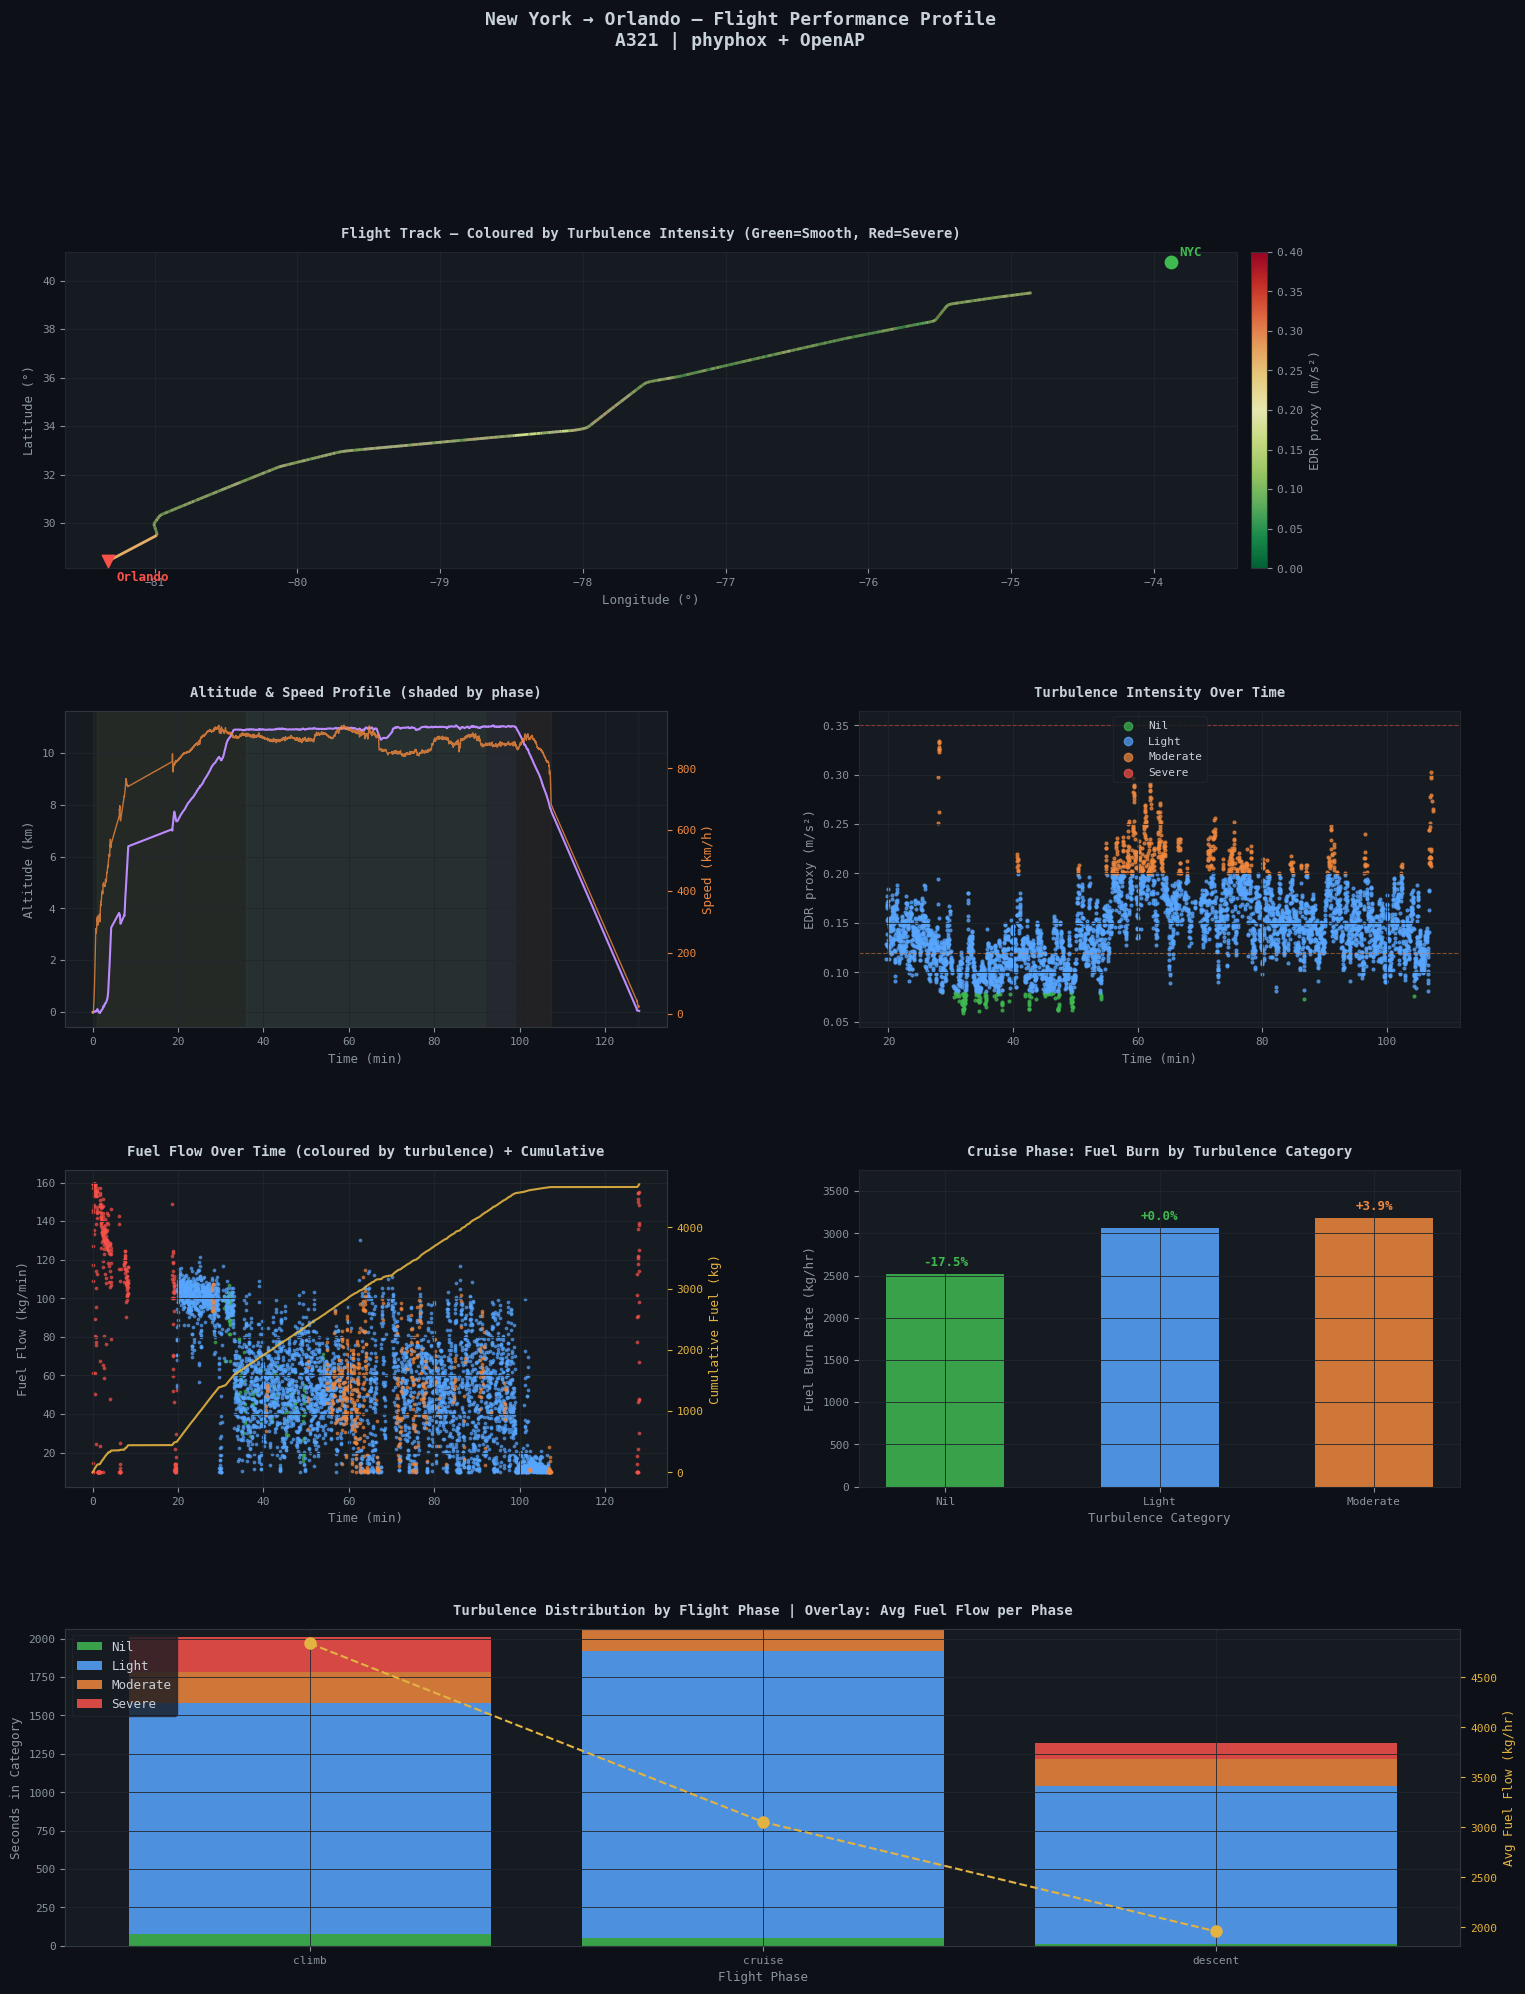

Saved nyc_orlando_dashboard.png


In [24]:
t_min = t / 60
fuel_flow_kgmin = fuel_flow * 60
fuel_cumulative = np.cumsum(fuel_flow) * dt

fig = plt.figure(figsize=(18, 22), facecolor=DARK)
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.32)

def style(ax, title):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.set_title(title, color=WHITE, fontweight='bold', fontsize=10, pad=10)
    ax.grid(True)

# Panel 1: Flight track coloured by turbulence
ax1 = fig.add_subplot(gs[0, :])
pts  = np.array([lon, lat]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
norm = Normalize(vmin=0, vmax=0.4)
lc   = LineCollection(segs, cmap='RdYlGn_r', norm=norm, lw=2, alpha=0.9)
lc.set_array(edr[:-1])
ax1.add_collection(lc)
cb = plt.colorbar(lc, ax=ax1, label='EDR proxy (m/s²)', pad=0.01)
cb.ax.yaxis.label.set_color(MUTED); cb.ax.tick_params(colors=MUTED)
ax1.set_xlim(lon.min()-0.3, lon.max()+0.3)
ax1.set_ylim(lat.min()-0.3, lat.max()+0.3)
ax1.set_xlabel('Longitude (\u00b0)'); ax1.set_ylabel('Latitude (\u00b0)')
ax1.scatter(lon[0], lat[0], color=GREEN, s=80, zorder=5)
ax1.scatter(lon[-1], lat[-1], color=RED, s=80, zorder=5, marker='v')
ax1.annotate('NYC',     (lon[0], lat[0]),  color=GREEN, fontsize=9, fontweight='bold', xytext=(6,4), textcoords='offset points')
ax1.annotate('Orlando', (lon[-1], lat[-1]), color=RED,   fontsize=9, fontweight='bold', xytext=(6,-14), textcoords='offset points')
style(ax1, 'Flight Track — Coloured by Turbulence Intensity (Green=Smooth, Red=Severe)')

# Panel 2: Altitude & speed with phase shading
ax2 = fig.add_subplot(gs[1, 0])
ax2b = ax2.twinx()
ax2.plot(t_min, alt_m/1000, color=PURPLE, lw=1.5, label='Altitude (km)')
ax2b.plot(t_min, vel_ms*3.6, color=ORANGE, lw=1.0, alpha=0.8, label='Speed (km/h)')
for p, c in PHASE_COLORS.items():
    idx = np.where(phase == p)[0]
    if len(idx) > 0:
        for grp_start, grp_end in zip(idx[:-1], idx[1:]):
            pass
        ax2.axvspan(t_min[idx[0]], t_min[idx[-1]], alpha=0.06, color=c)
ax2.set_xlabel('Time (min)'); ax2.set_ylabel('Altitude (km)', color=PURPLE)
ax2b.set_ylabel('Speed (km/h)', color=ORANGE)
ax2b.set_facecolor(PANEL); ax2b.tick_params(colors=ORANGE, labelsize=8); ax2b.grid(False)
style(ax2, 'Altitude & Speed Profile (shaded by phase)')

# Panel 3: EDR over time
ax3 = fig.add_subplot(gs[1, 1])
step = max(1, fs)  # downsample for plotting
for c, col in enumerate(CAT_COLORS):
    mask = cat == c
    ax3.scatter(t_min[mask][::step], edr[mask][::step], c=col, s=4, alpha=0.7, label=CAT_NAMES[c])
ax3.axhline(0.12, color=CAT_COLORS[2], lw=0.8, ls='--', alpha=0.5)
ax3.axhline(0.35, color=CAT_COLORS[3], lw=0.8, ls='--', alpha=0.5)
ax3.set_xlabel('Time (min)'); ax3.set_ylabel('EDR proxy (m/s²)')
ax3.legend(facecolor=PANEL, labelcolor=WHITE, edgecolor=GRID, fontsize=8, markerscale=3)
style(ax3, 'Turbulence Intensity Over Time')

# Panel 4: Fuel flow + cumulative
ax4  = fig.add_subplot(gs[2, 0])
ax4b = ax4.twinx()
for c, col in enumerate(CAT_COLORS):
    mask = cat == c
    ax4.scatter(t_min[mask][::step], fuel_flow_kgmin[mask][::step], c=col, s=3, alpha=0.6)
ax4b.plot(t_min, fuel_cumulative, color=YELLOW, lw=1.5, alpha=0.9)
ax4.set_xlabel('Time (min)'); ax4.set_ylabel('Fuel Flow (kg/min)', color=CYAN)
ax4b.set_ylabel('Cumulative Fuel (kg)', color=YELLOW)
ax4b.set_facecolor(PANEL); ax4b.tick_params(colors=YELLOW, labelsize=8); ax4b.grid(False)
style(ax4, 'Fuel Flow Over Time (coloured by turbulence) + Cumulative')

# Panel 5: Fuel by turbulence category (cruise)
ax5 = fig.add_subplot(gs[2, 1])
if 'cruise' in results and results['cruise']:
    cnames = list(results['cruise'].keys())
    kghrs  = [results['cruise'][n]['kghr'] for n in cnames]
    pcts   = [results['cruise'][n]['pct']  for n in cnames]
    bars = ax5.bar(cnames, kghrs,
                   color=[CAT_COLORS[CAT_NAMES.index(n)] for n in cnames],
                   alpha=0.85, width=0.55)
    for bar, pct in zip(bars, pcts):
        sign = '+' if pct >= 0 else ''
        col  = RED if pct > 10 else (ORANGE if pct > 0 else GREEN)
        ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(kghrs)*0.02,
                 f'{sign}{pct:.1f}%', ha='center', va='bottom', color=col,
                 fontsize=9, fontweight='bold')
    ax5.set_ylim(0, max(kghrs)*1.18)
ax5.set_xlabel('Turbulence Category'); ax5.set_ylabel('Fuel Burn Rate (kg/hr)')
style(ax5, 'Cruise Phase: Fuel Burn by Turbulence Category')

# Panel 6: Turbulence distribution by phase + avg fuel flow overlay
ax6 = fig.add_subplot(gs[3, :])
phases_order = [p for p in ['climb', 'level', 'cruise', 'descent'] if (phase==p).sum() > 0]
bottoms = np.zeros(len(phases_order))
for c, (col, cname) in enumerate(zip(CAT_COLORS, CAT_NAMES)):
    vals = [((phase==p) & (cat==c)).sum()/fs for p in phases_order]
    ax6.bar(phases_order, vals, bottom=bottoms, color=col, label=cname, alpha=0.85)
    bottoms += np.array(vals, dtype=float)
ax6b = ax6.twinx()
phase_ff = [fuel_flow[phase==p].mean()*3600 for p in phases_order]
ax6b.plot(phases_order, phase_ff, 'o--', color=YELLOW, lw=1.5, ms=8, label='Avg fuel flow (kg/hr)')
ax6b.set_ylabel('Avg Fuel Flow (kg/hr)', color=YELLOW)
ax6b.tick_params(colors=YELLOW, labelsize=8); ax6b.set_facecolor(PANEL); ax6b.grid(False)
ax6.set_xlabel('Flight Phase'); ax6.set_ylabel('Seconds in Category')
ax6.legend(facecolor=PANEL, labelcolor=WHITE, edgecolor=GRID, fontsize=9, loc='upper left')
style(ax6, 'Turbulence Distribution by Flight Phase | Overlay: Avg Fuel Flow per Phase')

fig.suptitle('New York \u2192 Orlando \u2014 Flight Performance Profile\n'
             f'{AC_TYPE} | phyphox + OpenAP', color=WHITE, fontsize=13, fontweight='bold', y=0.99)

plt.savefig('nyc_orlando_dashboard.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved nyc_orlando_dashboard.png')

In [25]:
export = pd.DataFrame({
    'time_s': t,
    'lat': lat, 'lon': lon, 'alt_m': alt_m, 'vel_ms': vel_ms, 'heading': hdg,
    'pitch': pitch, 'roll': roll, 'yaw': yaw,
    'lin_x': lin_x, 'lin_y': lin_y, 'lin_z': lin_z, 'gyr_mag': gyr_mag,
    'edr': edr, 'turb_cat': cat,
    'phase': phase,
    'fuel_flow_kgs': fuel_flow, 'co2_gs': co2, 'nox_gs': nox, 'co_gs': co,
})
out_path = os.path.join(DATA_DIR, 'merged_analysis.csv')
export.to_csv(out_path, index=False)
print(f'Exported merged dataframe to: {out_path}')
print(f'{len(export)} rows x {len(export.columns)} cols')

Exported merged dataframe to: /Users/ramupadhyay/Desktop/ny_to_florida_p/merged_analysis.csv
10869 rows x 20 cols
